# Server Evaluation

This File reads all csv files of the ./server folder and concatenates them to a single dataframe, then used for further evaluation.

In [82]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

In [83]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)
df["Distance (m)"] = df["Distance (m)"].replace(30,5)
df_filtered = df[df["Transfer Speed (Mbps)"] < 5000]

scenarios = df["Scenario"].unique()
scenarios.sort()

palette = sns.color_palette(n_colors=len(scenarios))
palette_dict = dict(zip(scenarios, palette))

In [84]:
df

,Transport Protocol,Scenario,Distance (m),Transfer Speed (Mbps),Package Loss (%),Package Size (Bytes),Number of Packages
0,UDP,Underground,1,285.483612,0.000000,4096,100
1,TCP,Underground,1,179.886841,0.000000,4096,100
2,QUIC,Forest,5,10.741581,0.000000,128,100
3,QUIC,Inner City,10,16.050913,0.000000,128,1000
4,UDP,Inner City,5,279.436005,66.479996,9216,10000
...,...,...,...,...,...,...,...
643,TCP,Field,5,29.589092,0.000000,4096,1000
644,TCP,Forest,10,2.621944,0.000000,128,100
645,QUIC,Underground,5,412.345062,0.000000,9216,10000
646,QUIC,Underground,5,16.328594,0.000000,128,1000


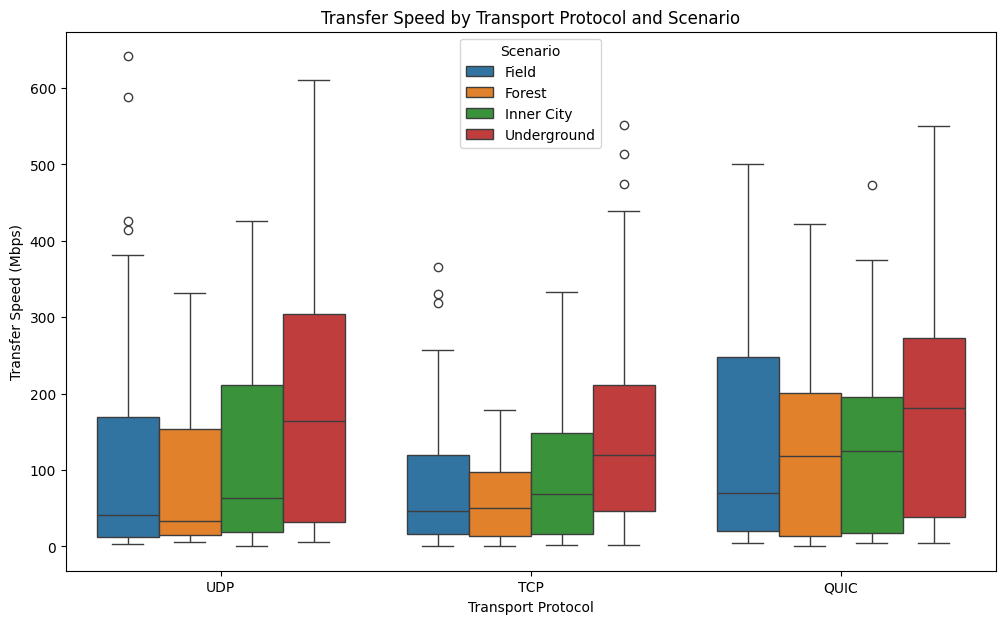

In [85]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Transport Protocol', y='Transfer Speed (Mbps)', hue='Scenario', data=df_filtered, palette=palette_dict, hue_order=scenarios)
plt.title('Transfer Speed by Transport Protocol and Scenario')
plt.ylabel('Transfer Speed (Mbps)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

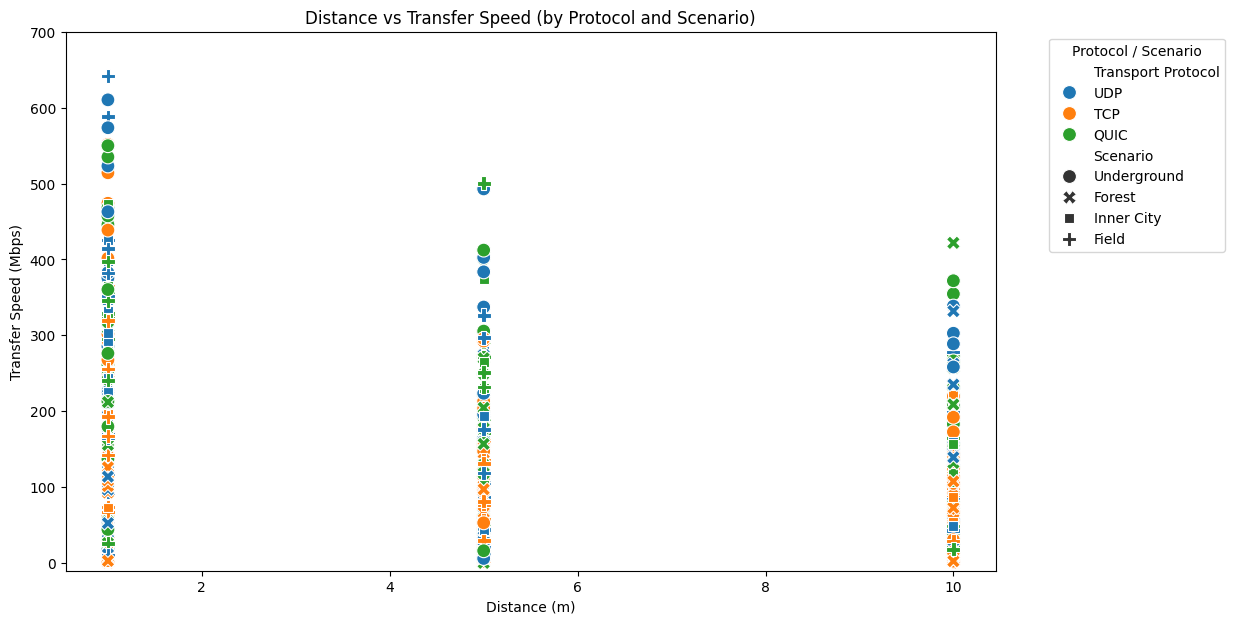

In [86]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Distance (m)', y='Transfer Speed (Mbps)', hue='Transport Protocol', style='Scenario', data=df, s=100)
plt.title('Distance vs Transfer Speed (by Protocol and Scenario)')
plt.ylim(-10,700)
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

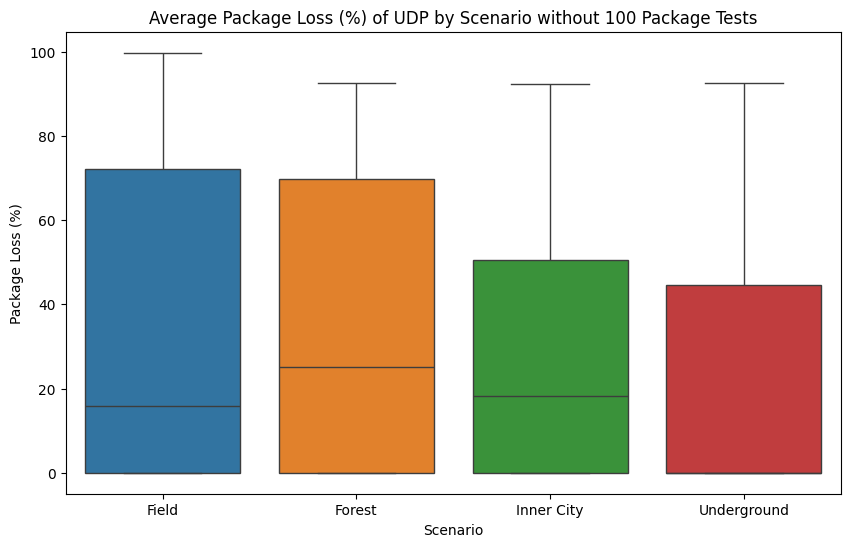

In [87]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Scenario', y='Package Loss (%)', hue='Scenario', data=df[(df["Transport Protocol"] == "UDP") & (df["Number of Packages"] >= 1000)], palette=palette_dict, order=scenarios)
plt.title('Average Package Loss (%) of UDP by Scenario without 100 Package Tests')
plt.ylabel('Package Loss (%)')
plt.xlabel('Scenario')
plt.show()

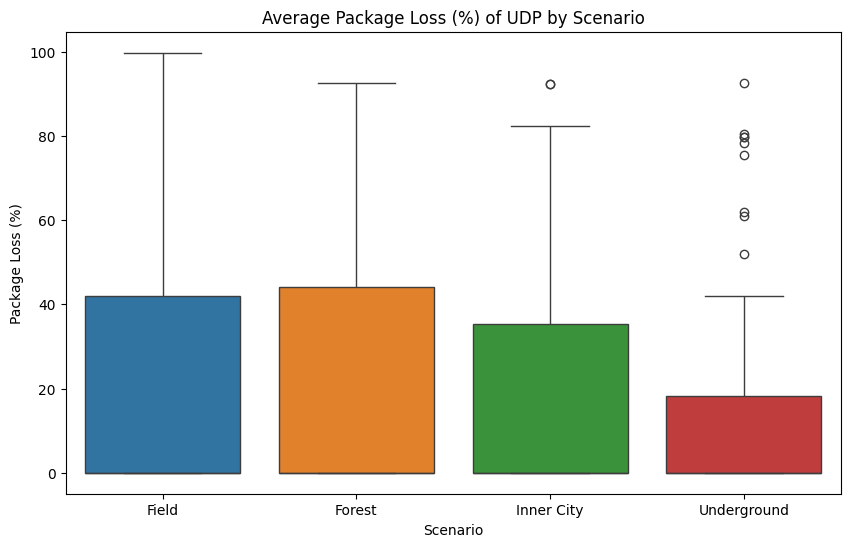

In [93]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Scenario', y='Package Loss (%)', hue='Scenario', data=df[df["Transport Protocol"] == "UDP"], palette=palette_dict, order=scenarios)
plt.title('Average Package Loss (%) of UDP by Scenario')
plt.ylabel('Package Loss (%)')
plt.xlabel('Scenario')
plt.show()

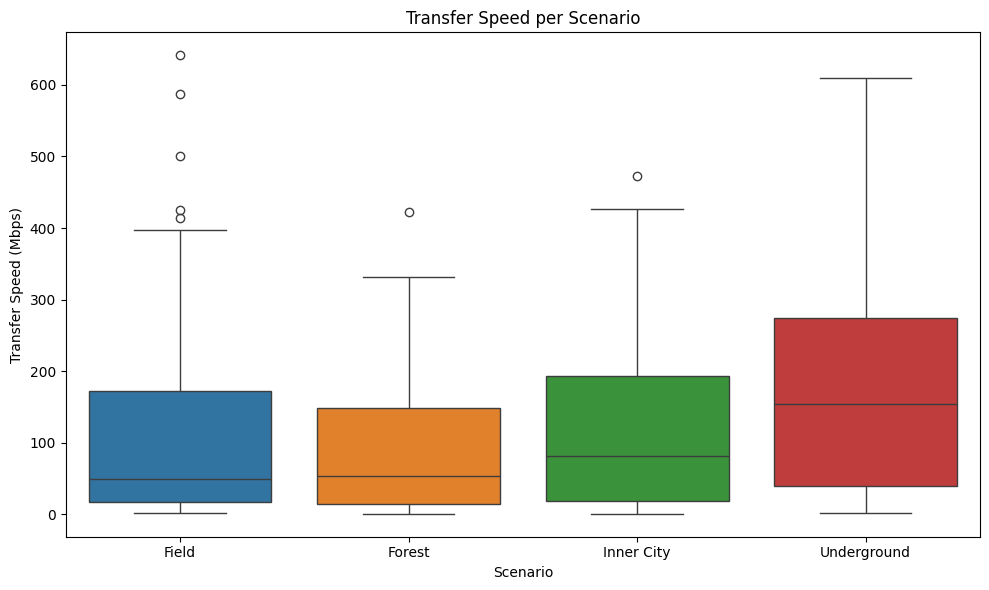

In [88]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Scenario', y='Transfer Speed (Mbps)', hue="Scenario", data=df_filtered, palette=palette_dict, order=scenarios)
plt.title('Transfer Speed per Scenario')
plt.ylabel('Transfer Speed (Mbps)')
plt.xlabel('Scenario')
plt.tight_layout()
plt.show()

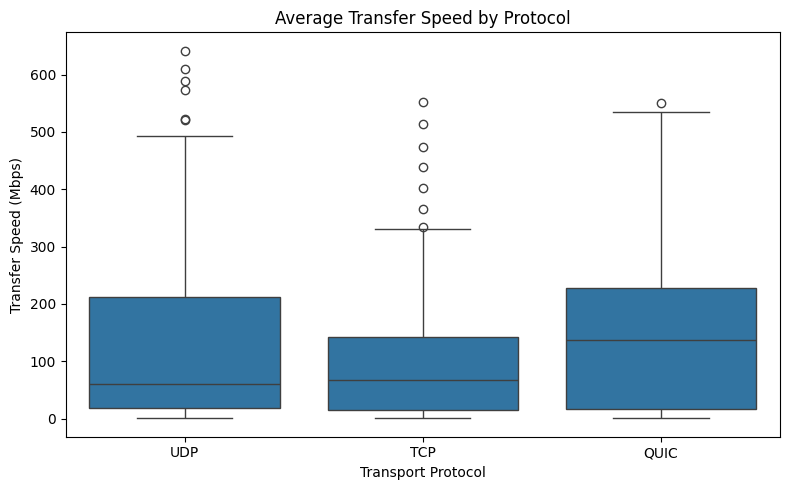

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Transport Protocol', y='Transfer Speed (Mbps)', data=df_filtered)
plt.title('Average Transfer Speed by Protocol')
plt.ylabel('Transfer Speed (Mbps)')
plt.xlabel('Transport Protocol')
plt.tight_layout()
plt.show()

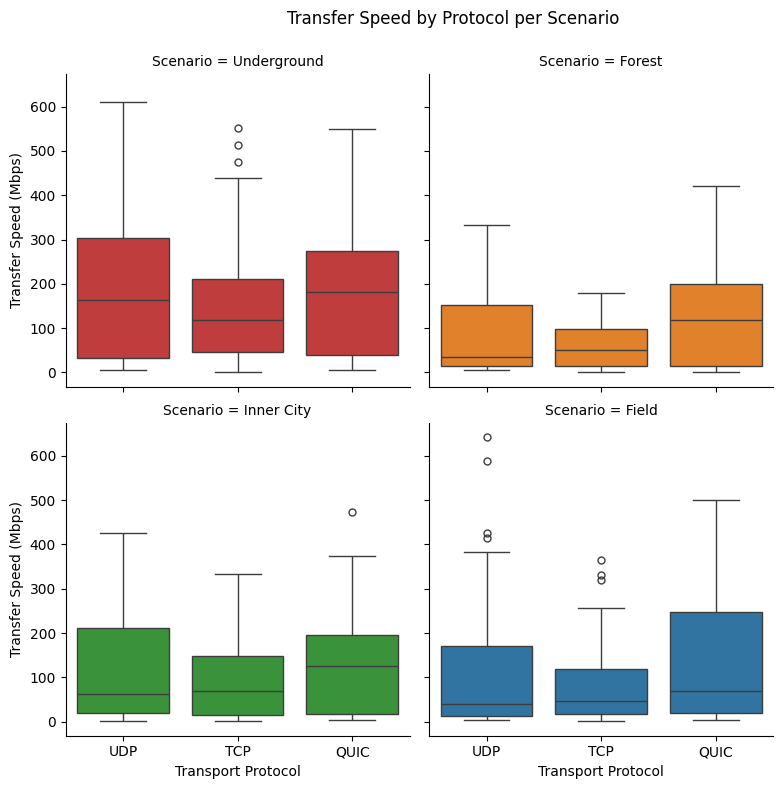

In [92]:
g = sns.catplot(
    data=df_filtered, kind="box",
    x="Transport Protocol", y="Transfer Speed (Mbps)",
    col="Scenario", col_wrap=2, height=4, hue="Scenario", palette=palette_dict, hue_order=scenarios
)
g.fig.subplots_adjust(top=0.9)
g._legend.remove()
g.fig.suptitle('Transfer Speed by Protocol per Scenario')

plt.show()